In [1]:
# ============================================================
# TODO EN UNA SOLA CELDA - COMPROBACIÓN DE BASES POR AÑO
# ============================================================

import os
import re
import zipfile
import hashlib
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

# ============================================================
# 1) CONFIGURACIÓN
# ============================================================
# Cambia esta ruta si tu ZIP está en otra ubicación
ZIP_PATH = "/content/Archivo.zip"
OUT_DIR = "/content/bases_extraidas"

# ============================================================
# 2) FUNCIONES AUXILIARES
# ============================================================
def md5_file(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()

def clasificar_archivo(nombre):
    """
    Ejemplo esperado:
    MX_FFQ_ANTRO_2020_2026-03-14.csv
    DIC_SALUD_2021_2026-03-13.csv
    """
    base = os.path.basename(nombre)
    m = re.match(r'^(MX|DIC)_(.+?)_(20\d{2})_\d{4}-\d{2}-\d{2}\.csv$', base)
    if m:
        tipo = m.group(1)      # MX o DIC
        tema = m.group(2)      # FFQ_ANTRO o SALUD
        anio = m.group(3)      # 2020, 2021, etc.
        return tipo, tema, anio
    return None, None, None

def detectar_columna(df, candidatos):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidatos:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

# ============================================================
# 3) DESCOMPRIMIR ZIP
# ============================================================
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"No se encontró el ZIP en: {ZIP_PATH}")

os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

print("=" * 80)
print("ZIP extraído correctamente")
print("Ruta ZIP:", ZIP_PATH)
print("Carpeta destino:", OUT_DIR)
print("=" * 80)

# ============================================================
# 4) BUSCAR TODOS LOS CSV
# ============================================================
csv_files = []
for root, _, files in os.walk(OUT_DIR):
    for f in files:
        if f.lower().endswith(".csv") and "__MACOSX" not in root and not f.startswith("._"):
            csv_files.append(os.path.join(root, f))

csv_files = sorted(csv_files)

if len(csv_files) == 0:
    raise ValueError("No se encontraron archivos CSV dentro del ZIP.")

print(f"\nTotal de CSV encontrados: {len(csv_files)}\n")
for f in csv_files:
    print(os.path.relpath(f, OUT_DIR))

# ============================================================
# 5) EVIDENCIA DE EXISTENCIA DE ARCHIVOS
# ============================================================
evidencia = []
for path in csv_files:
    evidencia.append({
        "archivo": os.path.relpath(path, OUT_DIR),
        "existe": os.path.exists(path),
        "tam_MB": round(os.path.getsize(path) / (1024 ** 2), 3),
        "md5": md5_file(path)
    })

df_evidencia = pd.DataFrame(evidencia)
display(Markdown("# Evidencia de archivos extraídos"))
display(df_evidencia)

evidencia_csv = "/content/evidencia_archivos.csv"
df_evidencia.to_csv(evidencia_csv, index=False, encoding="utf-8-sig")
print(f"\nArchivo guardado: {evidencia_csv}")

# ============================================================
# 6) CARGAR BASES Y DICCIONARIOS
# ============================================================
bases = {}         # bases[año][tema] = DataFrame
diccionarios = {}  # diccionarios[año][tema] = DataFrame
resumen_archivos = []

for path in csv_files:
    tipo, tema, anio = clasificar_archivo(path)

    if tipo is None:
        print(f"Advertencia: no se pudo clasificar -> {os.path.basename(path)}")
        continue

    try:
        df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    except Exception:
        df = pd.read_csv(path, low_memory=False)

    if anio not in bases:
        bases[anio] = {}
    if anio not in diccionarios:
        diccionarios[anio] = {}

    if tipo == "MX":
        bases[anio][tema] = df
    else:
        diccionarios[anio][tema] = df

    resumen_archivos.append({
        "anio": anio,
        "tipo_archivo": tipo,
        "tema": tema,
        "archivo": os.path.basename(path),
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "tam_MB": round(os.path.getsize(path) / (1024 ** 2), 3)
    })

df_resumen_archivos = pd.DataFrame(resumen_archivos).sort_values(["anio", "tipo_archivo", "tema"])
display(Markdown("# Tamaño de matrices / tablas por año"))
display(df_resumen_archivos)

resumen_matrices_csv = "/content/resumen_matrices_por_anio.csv"
df_resumen_archivos.to_csv(resumen_matrices_csv, index=False, encoding="utf-8-sig")
print(f"Archivo guardado: {resumen_matrices_csv}")

# ============================================================
# 7) CREAR VARIABLES EXPLÍCITAS EN MEMORIA
# ============================================================
for anio, temas in bases.items():
    for tema, df in temas.items():
        nombre_variable = f"MX_{tema}_{anio}"
        globals()[nombre_variable] = df

for anio, temas in diccionarios.items():
    for tema, df in temas.items():
        nombre_variable = f"DIC_{tema}_{anio}"
        globals()[nombre_variable] = df

variables_creadas = sorted([
    k for k in globals().keys()
    if re.match(r'^(MX|DIC)_.+_20\d{2}$', k)
])

display(Markdown("# Variables creadas en memoria"))
for v in variables_creadas:
    print(f"{v:25s} -> shape = {globals()[v].shape}")

# ============================================================
# 8) RESUMEN DE VARIABLES Y CUESTIONARIOS
# ============================================================
resumen_variables = []

for anio in sorted(diccionarios.keys()):
    for tema, dfdic in diccionarios[anio].items():

        col_var = detectar_columna(dfdic, ["var", "variable"])
        col_alias = detectar_columna(dfdic, ["var_alias", "alias"])
        col_subcat = detectar_columna(dfdic, ["subcategoria", "subcategoría", "cuestionario", "questionnaire", "modulo", "módulo"])

        vars_dic = dfdic[col_var].dropna().astype(str).unique().tolist() if col_var else []
        vars_alias = dfdic[col_alias].dropna().astype(str).unique().tolist() if col_alias else []
        subcategorias = dfdic[col_subcat].dropna().astype(str).unique().tolist() if col_subcat else []

        resumen_variables.append({
            "anio": anio,
            "tema": tema,
            "n_variables_diccionario": len(vars_dic),
            "n_alias": len(vars_alias),
            "n_subcategorias_cuestionario": len(subcategorias),
            "primeras_10_subcategorias": " | ".join(subcategorias[:10]) if len(subcategorias) > 0 else ""
        })

df_resumen_variables = pd.DataFrame(resumen_variables).sort_values(["anio", "tema"])
display(Markdown("# Resumen de variables y cuestionarios por año"))
display(df_resumen_variables)

resumen_vars_csv = "/content/resumen_variables_cuestionarios_por_anio.csv"
df_resumen_variables.to_csv(resumen_vars_csv, index=False, encoding="utf-8-sig")
print(f"Archivo guardado: {resumen_vars_csv}")

# ============================================================
# 9) MOSTRAR DETALLE COMPLETO POR AÑO
# ============================================================
for anio in sorted(set(list(bases.keys()) + list(diccionarios.keys()))):
    display(Markdown(f"# Año {anio}"))

    temas = sorted(set(list(bases.get(anio, {}).keys()) + list(diccionarios.get(anio, {}).keys())))

    for tema in temas:
        display(Markdown(f"## {tema}"))

        # -------------------------
        # MATRIZ / BASE
        # -------------------------
        if tema in bases.get(anio, {}):
            df_base = bases[anio][tema]
            display(Markdown("### Matriz / base"))
            print("Shape:", df_base.shape)
            print("Número total de variables en la matriz:", len(df_base.columns))
            print("Primeras 30 variables de la matriz:")
            print(df_base.columns.tolist()[:30])
            display(df_base.head(3))

        # -------------------------
        # DICCIONARIO
        # -------------------------
        if tema in diccionarios.get(anio, {}):
            df_dic = diccionarios[anio][tema]
            display(Markdown("### Diccionario"))
            print("Shape:", df_dic.shape)
            print("Columnas del diccionario:")
            print(df_dic.columns.tolist())

            col_var = detectar_columna(df_dic, ["var", "variable"])
            col_alias = detectar_columna(df_dic, ["var_alias", "alias"])
            col_subcat = detectar_columna(df_dic, ["subcategoria", "subcategoría", "cuestionario", "questionnaire", "modulo", "módulo"])

            if col_subcat:
                subs = df_dic[col_subcat].dropna().astype(str).unique().tolist()
                print(f"\nCuestionarios / subcategorías ({len(subs)}):")
                print(subs[:50])

            if col_var:
                vars_dic = df_dic[col_var].dropna().astype(str).unique().tolist()
                print(f"\nVariables documentadas ({len(vars_dic)}):")
                print(vars_dic[:80])

            if col_alias:
                alias_dic = df_dic[col_alias].dropna().astype(str).unique().tolist()
                print(f"\nAlias de variables ({len(alias_dic)}):")
                print(alias_dic[:80])

            display(df_dic.head(10))

        print("\n" + "-" * 100 + "\n")

# ============================================================
# 10) RESUMEN FINAL POR AÑO
# ============================================================
resumen_final = []

for anio in sorted(set(list(bases.keys()) + list(diccionarios.keys()))):
    fila = {"anio": anio}

    for tema, df in bases.get(anio, {}).items():
        fila[f"MX_{tema}_filas"] = df.shape[0]
        fila[f"MX_{tema}_columnas"] = df.shape[1]

    for tema, df in diccionarios.get(anio, {}).items():
        fila[f"DIC_{tema}_filas"] = df.shape[0]
        fila[f"DIC_{tema}_columnas"] = df.shape[1]

        col_var = detectar_columna(df, ["var", "variable"])
        col_subcat = detectar_columna(df, ["subcategoria", "subcategoría", "cuestionario", "questionnaire", "modulo", "módulo"])

        fila[f"DIC_{tema}_n_variables"] = df[col_var].dropna().astype(str).nunique() if col_var else None
        fila[f"DIC_{tema}_n_subcategorias"] = df[col_subcat].dropna().astype(str).nunique() if col_subcat else None

    resumen_final.append(fila)

df_resumen_final = pd.DataFrame(resumen_final).sort_values("anio")
display(Markdown("# Resumen final por año"))
display(df_resumen_final)

resumen_final_csv = "/content/resumen_final_por_anio.csv"
df_resumen_final.to_csv(resumen_final_csv, index=False, encoding="utf-8-sig")
print(f"Archivo guardado: {resumen_final_csv}")

# ============================================================
# 11) MENSAJE FINAL DE EVIDENCIA
# ============================================================
print("\n" + "=" * 80)
print("PROCESO TERMINADO")
print("Se comprobó la extracción, existencia y carga de las bases.")
print("También se mostraron:")
print("- archivos existentes")
print("- hashes MD5")
print("- tamaños de matrices")
print("- variables")
print("- cuestionarios / subcategorías")
print("- resumen por año")
print("\nArchivos de salida:")
print("1.", evidencia_csv)
print("2.", resumen_matrices_csv)
print("3.", resumen_vars_csv)
print("4.", resumen_final_csv)
print("=" * 80)

ZIP extraído correctamente
Ruta ZIP: /content/Archivo.zip
Carpeta destino: /content/bases_extraidas

Total de CSV encontrados: 20

2020/DIC_FFQ_ANTRO_2020_2026-03-14.csv
2020/DIC_SALUD_2020_2026-03-14.csv
2020/MX_FFQ_ANTRO_2020_2026-03-14.csv
2020/MX_SALUD_2020_2026-03-14.csv
2021/DIC_FFQ_ANTRO_2021_2026-03-14.csv
2021/DIC_SALUD_2021_2026-03-13.csv
2021/MX_FFQ_ANTRO_2021_2026-03-14.csv
2021/MX_SALUD_2021_2026-03-13.csv
2022/DIC_FFQ_ANTRO_2022_2026-03-14.csv
2022/DIC_SALUD_2022_2026-03-14.csv
2022/MX_FFQ_ANTRO_2022_2026-03-14.csv
2022/MX_SALUD_2022_2026-03-14.csv
2023/DIC_FFQ_ANTRO_2023_2026-03-13.csv
2023/DIC_SALUD_2023_2026-03-13.csv
2023/MX_FFQ_ANTRO_2023_2026-03-13.csv
2023/MX_SALUD_2023_2026-03-13.csv
2024/DIC_FFQ_ANTRO_2024_2026-03-13.csv
2024/DIC_SALUD_2024_2026-03-13.csv
2024/MX_FFQ_ANTRO_2024_2026-03-13.csv
2024/MX_SALUD_2024_2026-03-13.csv


# Evidencia de archivos extraídos

,archivo,existe,tam_MB,md5
0,2020/DIC_FFQ_ANTRO_2020_2026-03-14.csv,True,0.094,36e0549296c2ea15f2a27e3e16cc0aa2
1,2020/DIC_SALUD_2020_2026-03-14.csv,True,0.301,77081a91f188bdf97a9a73133b70db76
2,2020/MX_FFQ_ANTRO_2020_2026-03-14.csv,True,7.764,47b5b028453f7083b2f9b3b07c3c3734
3,2020/MX_SALUD_2020_2026-03-14.csv,True,58.687,cb889c34a90f8584a31222b19261306e
4,2021/DIC_FFQ_ANTRO_2021_2026-03-14.csv,True,0.095,f8e2d579140f3aaa9908f9afd30af640
5,2021/DIC_SALUD_2021_2026-03-13.csv,True,0.747,f82d70e2e41f1d8bdfcaa793f368c40b
6,2021/MX_FFQ_ANTRO_2021_2026-03-14.csv,True,11.035,301019b84c7c16ab355a09be93b6d7b2
7,2021/MX_SALUD_2021_2026-03-13.csv,True,134.844,16f2ebc6c6268e36ef9a5e74608db932
8,2022/DIC_FFQ_ANTRO_2022_2026-03-14.csv,True,0.094,e3785e35bddb2cb37759081593377586
9,2022/DIC_SALUD_2022_2026-03-14.csv,True,0.547,cc82c73ef122db9f3b19fb45f9f862b3



Archivo guardado: /content/evidencia_archivos.csv


# Tamaño de matrices / tablas por año

...

,subcategoria,var,var_alias,description,values
0,SALUD ADOLESCENTES,FOLIO_I,FOLIO_I,Folio,"{""is_category"":""false"",""min"":0,""max"":0}"
1,SALUD ADOLESCENTES,FOLIO_INT,FOLIO_INT,Folio integrante,"{""is_category"":""false"",""min"":0,""max"":0}"
2,SALUD ADOLESCENTES,ENTIDAD,ENTIDAD,Entidad,"{""is_category"":""false"",""min"":0,""max"":0}"
3,SALUD ADOLESCENTES,DESC_ENT,DESC_ENT,DESC_ENT,"{""is_category"":""false"",""min"":0,""max"":0}"
4,SALUD ADOLESCENTES,MUNICIPIO,MUNICIPIO,Municipio,"{""is_category"":""false"",""min"":0,""max"":0}"
5,SALUD ADOLESCENTES,DESC_MUN,DESC_MUN,DESC_MUN,"{""is_category"":""false"",""min"":0,""max"":0}"
6,SALUD ADOLESCENTES,FECH_NAC,FECH_NAC,Fecha de Nacimiento,"{""is_category"":""false"",""min"":0,""max"":0}"
7,SALUD ADOLESCENTES,MESES,MESES,Meses edad,"{""is_category"":""false"",""min"":0,""max"":0}"
8,SALUD ADOLESCENTES,DSEXO,DSEXO,DSEXO ¿Cuál es el sexo de (NOMBRE) ?,"{""is_category"":""true"",""options"":{""1"":""Hombre"",..."
9,SALUD ADOLESCENTES,DEDAD,DEDAD,DEDAD (NOMBRE) ¿Cuántos años cumplidos tienes ...,"{""is_category"":""true"",""options"":{""999"":""NS/NR""}}"



----------------------------------------------------------------------------------------------------



# Resumen final por año

,anio,MX_FFQ_ANTRO_filas,MX_FFQ_ANTRO_columnas,MX_SALUD_filas,MX_SALUD_columnas,DIC_FFQ_ANTRO_filas,DIC_FFQ_ANTRO_columnas,DIC_FFQ_ANTRO_n_variables,DIC_FFQ_ANTRO_n_subcategorias,DIC_SALUD_filas,DIC_SALUD_columnas,DIC_SALUD_n_variables,DIC_SALUD_n_subcategorias
0,2020,15115,321,36103,1085,316,5,316,4,1085,5,1085,7
1,2021,16062,321,43724,2268,316,5,316,4,2268,5,2268,9
2,2022,15102,318,36483,1785,314,5,314,4,1785,5,1785,11
3,2023,9433,321,20018,2288,318,5,318,4,2288,5,2288,11
4,2024,17667,320,36021,2368,317,5,317,4,2368,5,2368,12


Archivo guardado: /content/resumen_final_por_anio.csv

PROCESO TERMINADO
Se comprobó la extracción, existencia y carga de las bases.
También se mostraron:
- archivos existentes
- hashes MD5
- tamaños de matrices
- variables
- cuestionarios / subcategorías
- resumen por año

Archivos de salida:
1. /content/evidencia_archivos.csv
2. /content/resumen_matrices_por_anio.csv
3. /content/resumen_variables_cuestionarios_por_anio.csv
4. /content/resumen_final_por_anio.csv


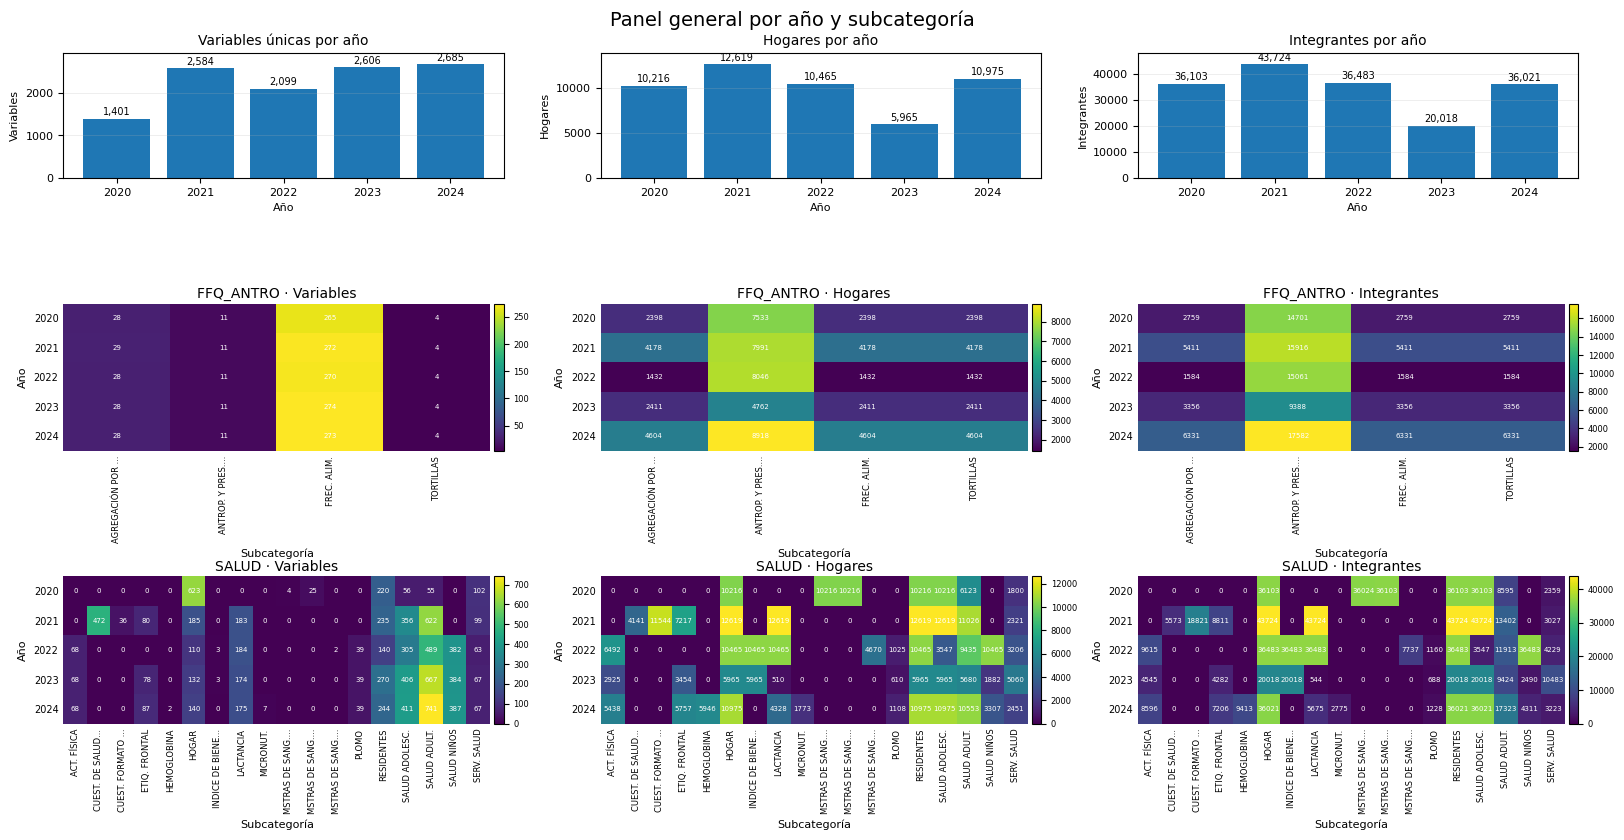

Archivos guardados:
/content/panel_general_compacto.png
/content/panel_general_compacto.pdf


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# REQUISITO
# Deben existir:
# - df_resumen
# - df_total_anio
# ============================================================
if "df_resumen" not in globals():
    raise ValueError("No existe 'df_resumen'.")

if "df_total_anio" not in globals():
    raise ValueError("No existe 'df_total_anio'.")

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def acortar_etiqueta(txt, max_len=18):
    txt = str(txt).strip()
    reemplazos = {
        "CUESTIONARIO DE SALUD EN MENORES": "SALUD MENORES",
        "CUESTIONARIO DE SALUD DE LOS ADULTOS": "SALUD ADULTOS",
        "CUESTIONARIO DE SALUD DE LOS ADOLESCENTES": "SALUD ADOLESC.",
        "CUESTIONARIO": "CUEST.",
        "MUESTRAS": "MSTRAS",
        "SANGRE": "SANG.",
        "MICRONUTRIENTES": "MICRONUT.",
        "ANTROPOMETRÍA": "ANTROP.",
        "ANTROPOMETRIA": "ANTROP.",
        "FRECUENCIA DE ALIMENTOS": "FREC. ALIM.",
        "PRESIÓN ARTERIAL": "PRES. ART.",
        "PRESION ARTERIAL": "PRES. ART.",
        "SERVICIOS SALUD": "SERV. SALUD",
        "ACTIVIDAD FÍSICA": "ACT. FÍSICA",
        "ACTIVIDAD FISICA": "ACT. FÍSICA",
        "ETIQUETADO FRONTAL": "ETIQ. FRONTAL",
        "SALUD ADOLESCENTES": "SALUD ADOLESC.",
        "SALUD ADULTOS": "SALUD ADULT.",
    }
    txt_up = txt.upper()
    for k, v in reemplazos.items():
        txt_up = txt_up.replace(k, v)
    if len(txt_up) > max_len:
        txt_up = txt_up[:max_len-3] + "..."
    return txt_up

def dibujar_barra(ax, x, y, titulo, ylabel):
    ax.bar(x, y)
    ax.set_title(titulo, fontsize=10, pad=6)
    ax.set_xlabel("Año", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.margins(y=0.10)

    ymax = np.nanmax(y) if len(y) > 0 else 0
    for i, v in enumerate(y):
        if pd.notna(v):
            ax.text(i, v + ymax * 0.015, f"{int(v):,}", ha="center", va="bottom", fontsize=7)

def dibujar_heatmap_compacto(ax, tabla, titulo, mostrar_texto=True):
    if tabla.empty:
        ax.axis("off")
        ax.set_title(f"{titulo}\n(sin datos)", fontsize=10)
        return

    tabla = tabla.copy()
    tabla.columns = [acortar_etiqueta(c, max_len=18) for c in tabla.columns]

    im = ax.imshow(tabla.values, aspect="auto", interpolation="nearest")

    ax.set_title(titulo, fontsize=10, pad=4)
    ax.set_xlabel("Subcategoría", fontsize=8, labelpad=4)
    ax.set_ylabel("Año", fontsize=8)

    ax.set_xticks(np.arange(tabla.shape[1]))
    ax.set_xticklabels(tabla.columns, rotation=90, fontsize=6)
    ax.set_yticks(np.arange(tabla.shape[0]))
    ax.set_yticklabels(tabla.index.astype(str), fontsize=7)

    # Bordes más limpios
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)

    # Texto dentro de celdas
    if mostrar_texto:
        nrows, ncols = tabla.shape
        if ncols <= 18:
            for i in range(nrows):
                for j in range(ncols):
                    valor = tabla.iloc[i, j]
                    if pd.notna(valor):
                        texto = f"{int(valor)}" if float(valor).is_integer() else f"{valor:.1f}"
                        ax.text(j, i, texto, ha="center", va="center", fontsize=5, color="white")

    # Colorbar compacta
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.2%", pad=0.04)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=6)

# ============================================================
# PREPARAR TEMAS Y TAMAÑO DINÁMICO
# ============================================================
temas = sorted(df_resumen["tema"].dropna().unique().tolist())
n_temas = len(temas)

# columnas máximas para estimar ancho
max_subcats = 1
for tema in temas:
    ncols_tema = df_resumen[df_resumen["tema"] == tema]["cuestionario_subcategoria"].nunique()
    max_subcats = max(max_subcats, ncols_tema)

# tamaño más compacto
fig_w = min(max(16, max_subcats * 0.9), 24)
fig_h = 2.8 + n_temas * 2.5

fig, axes = plt.subplots(
    1 + n_temas, 3,
    figsize=(fig_w, fig_h),
    gridspec_kw={
        "height_ratios": [0.85] + [1.0] * n_temas,
        "hspace": 0.9,
        "wspace": 0.22
    }
)

if (1 + n_temas) == 1:
    axes = np.array([axes])

# ============================================================
# FILA SUPERIOR
# ============================================================
dibujar_barra(
    axes[0, 0],
    df_total_anio["anio"].astype(str),
    df_total_anio["variables_unicas"],
    "Variables únicas por año",
    "Variables"
)

dibujar_barra(
    axes[0, 1],
    df_total_anio["anio"].astype(str),
    df_total_anio["hogares_referencia_salud"],
    "Hogares por año",
    "Hogares"
)

dibujar_barra(
    axes[0, 2],
    df_total_anio["anio"].astype(str),
    df_total_anio["integrantes_referencia_salud"],
    "Integrantes por año",
    "Integrantes"
)

# ============================================================
# HEATMAPS POR TEMA
# ============================================================
for idx, tema in enumerate(temas, start=1):
    df_tema = df_resumen[df_resumen["tema"] == tema].copy()

    tabla_variables = (
        df_tema.pivot_table(
            index="anio",
            columns="cuestionario_subcategoria",
            values="n_variables",
            aggfunc="sum"
        )
        .fillna(0)
        .sort_index()
    )

    tabla_hogares = (
        df_tema.pivot_table(
            index="anio",
            columns="cuestionario_subcategoria",
            values="n_hogares",
            aggfunc="first"
        )
        .fillna(0)
        .sort_index()
    )

    tabla_integrantes = (
        df_tema.pivot_table(
            index="anio",
            columns="cuestionario_subcategoria",
            values="n_integrantes",
            aggfunc="first"
        )
        .fillna(0)
        .sort_index()
    )

    dibujar_heatmap_compacto(
        axes[idx, 0],
        tabla_variables,
        f"{tema} · Variables"
    )
    dibujar_heatmap_compacto(
        axes[idx, 1],
        tabla_hogares,
        f"{tema} · Hogares"
    )
    dibujar_heatmap_compacto(
        axes[idx, 2],
        tabla_integrantes,
        f"{tema} · Integrantes"
    )

# ============================================================
# AJUSTES FINALES
# ============================================================
fig.suptitle(
    "Panel general por año y subcategoría",
    fontsize=14,
    y=0.995
)

plt.subplots_adjust(
    top=0.94,
    bottom=0.08,
    left=0.05,
    right=0.985,
    hspace=0.85,
    wspace=0.22
)

ruta_png = "/content/panel_general_compacto.png"
ruta_pdf = "/content/panel_general_compacto.pdf"

plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
plt.savefig(ruta_pdf, bbox_inches="tight")
plt.show()

print("Archivos guardados:")
print(ruta_png)
print(ruta_pdf)